# Setup


In [1]:
!pip install -q ucimlrepo


# Lib


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from imblearn.under_sampling import EditedNearestNeighbours
from sklearn.datasets import make_moons
from ucimlrepo import fetch_ucirepo


# Data Preparation


## Two Moons (Minh họa ENN)


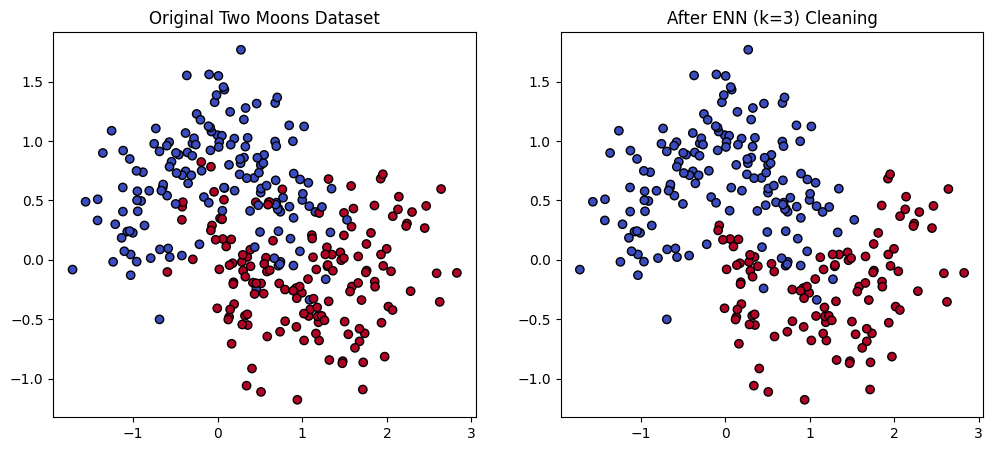

In [3]:
X_moons, y_moons = make_moons(n_samples=300, noise=0.3, random_state=42)

enn_illustrator = EditedNearestNeighbours(n_neighbors=3)
X_moons_resampled, y_moons_resampled = enn_illustrator.fit_resample(X_moons, y_moons)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='coolwarm', edgecolors='k')
ax1.set_title('Original Two Moons Dataset')
ax2.scatter(X_moons_resampled[:, 0], X_moons_resampled[:, 1], c=y_moons_resampled, cmap='coolwarm', edgecolors='k')
ax2.set_title('After ENN (k=3) Cleaning')
plt.show()


## Load data UCI Waveform Database Generator (Version 1)


In [4]:
# fetch dataset
waveform_database_generator_version_1 = fetch_ucirepo(id=107)

# data (as pandas dataframes)
X = waveform_database_generator_version_1.data.features
y = waveform_database_generator_version_1.data.targets

# Flatten y for scikit-learn compatibility
y = y.values.ravel()

print('Dataset shape X:', X.shape)
print('Phân phối class ban đầu:')
print(pd.Series(y).value_counts())


Dataset shape X: (5000, 21)
Phân phối class ban đầu:
2    1696
0    1657
1    1647
Name: count, dtype: int64


## Chia Dữ Liệu


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print('Kích thước tập train:', X_train.shape)
print('Kích thước tập test:', X_test.shape)


Kích thước tập train: (3500, 21)
Kích thước tập test: (1500, 21)


## Chuẩn Hóa Dữ Liệu


In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
# Chỉ biến đổi test set theo scaler đã học từ train set
X_test_scaled = scaler.transform(X_test)


# Architecture & Func


## Các hàm đánh giá và xử lý


In [7]:
def evaluate_model(y_true, y_pred, model_name='Model'):
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="weighted")
    recall = recall_score(y_true, y_pred, average="weighted")
    f1_weighted = f1_score(y_true, y_pred, average="weighted")
    f1_macro = f1_score(y_true, y_pred, average="macro")

    print(f"========================================")
    print(f"{model_name}")
    print(f"========================================")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-score  : {f1_weighted:.4f}")
    print(f"Macro F1  : {f1_macro:.4f}")
    print("\n========== CONFUSION MATRIX ==========")
    print(confusion_matrix(y_true, y_pred))
    print("\n========== CLASSIFICATION REPORT ==========")
    print(classification_report(y_true, y_pred))

    return {
        'Model': model_name,
        'Accuracy': acc,
        'Precision': precision,
        'Recall': recall,
        'F1_Weighted': f1_weighted,
        'F1_Macro': f1_macro
    }

# Main


## Kịch bản 1: Không dùng ENN


In [8]:
# Huấn luyện mô hình KNN (k=5) trên tập train ban đầu
knn_original = KNeighborsClassifier(n_neighbors=5)
knn_original.fit(X_train_scaled, y_train)

y_pred_original = knn_original.predict(X_test_scaled)
res_original = evaluate_model(y_test, y_pred_original, 'KNN (No ENN)')


KNN (No ENN)
Accuracy  : 0.8240
Precision : 0.8269
Recall    : 0.8240
F1-score  : 0.8227
Macro F1  : 0.8226

========== CONFUSION MATRIX ==========
[[362  69  66]
 [ 27 431  36]
 [ 30  36 443]]

========== CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

           0       0.86      0.73      0.79       497
           1       0.80      0.87      0.84       494
           2       0.81      0.87      0.84       509

    accuracy                           0.82      1500
   macro avg       0.83      0.82      0.82      1500
weighted avg       0.83      0.82      0.82      1500



## Kịch bản 2: Áp dụng ENN


In [9]:
results = [res_original]
enn_values = [3, 5, 7]

for k in enn_values:
    # 1. Apply ENN
    enn = EditedNearestNeighbours(n_neighbors=k, sampling_strategy="all", kind_sel="all")
    X_train_enn, y_train_enn = enn.fit_resample(X_train_scaled, y_train)

    # 2. Sample Analysis
    before_samples = len(y_train)
    after_samples = len(y_train_enn)
    print(f"\nENN EXPERIMENT - k = {k}")
    print("========== SAMPLE ANALYSIS ==========")
    print(f"Before ENN : {before_samples}")
    print(f"After ENN  : {after_samples}")
    print(f"Removed    : {before_samples - after_samples}")

    # 3. Class Analysis
    orig_counts = pd.Series(y_train).value_counts().sort_index()
    enn_counts = pd.Series(y_train_enn).value_counts().sort_index()
    print("========== REMOVED SAMPLES BY CLASS ==========")
    for class_label in sorted(orig_counts.index):
        removed = orig_counts[class_label] - enn_counts.get(class_label, 0)
        print(f"Removed Class {class_label}: {removed}")

    # 4. Train and Evaluate
    knn_enn = KNeighborsClassifier(n_neighbors=5)
    knn_enn.fit(X_train_enn, y_train_enn)
    y_pred_enn = knn_enn.predict(X_test_scaled)

    res_enn = evaluate_model(y_test, y_pred_enn, f'ENN k={k}')
    results.append(res_enn)


ENN EXPERIMENT - k = 3
========== SAMPLE ANALYSIS ==========
Before ENN : 3500
After ENN  : 1839
Removed    : 1661
========== REMOVED SAMPLES BY CLASS ==========
Removed Class 0: 614
Removed Class 1: 504
Removed Class 2: 543
ENN k=3
Accuracy  : 0.8320
Precision : 0.8434
Recall    : 0.8320
F1-score  : 0.8292
Macro F1  : 0.8290

========== CONFUSION MATRIX ==========
[[339  88  70]
 [ 14 445  35]
 [ 12  33 464]]

========== CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

           0       0.93      0.68      0.79       497
           1       0.79      0.90      0.84       494
           2       0.82      0.91      0.86       509

    accuracy                           0.83      1500
   macro avg       0.84      0.83      0.83      1500
weighted avg       0.84      0.83      0.83      1500


ENN EXPERIMENT - k = 5
========== SAMPLE ANALYSIS ==========
Before ENN : 3500
After ENN  : 1465
Removed    : 2035
========== REMOVED SAMPLES BY CLASS =======

# Evaluation / So sánh


,Model,Accuracy,Precision,Recall,F1_Weighted,F1_Macro
0,KNN (No ENN),0.824,0.826903,0.824,0.822746,0.822631
1,ENN k=3,0.832,0.843374,0.832,0.829240,0.829006
2,ENN k=5,0.838,0.847683,0.838,0.835539,0.835328
3,ENN k=7,0.838,0.848495,0.838,0.835425,0.835164


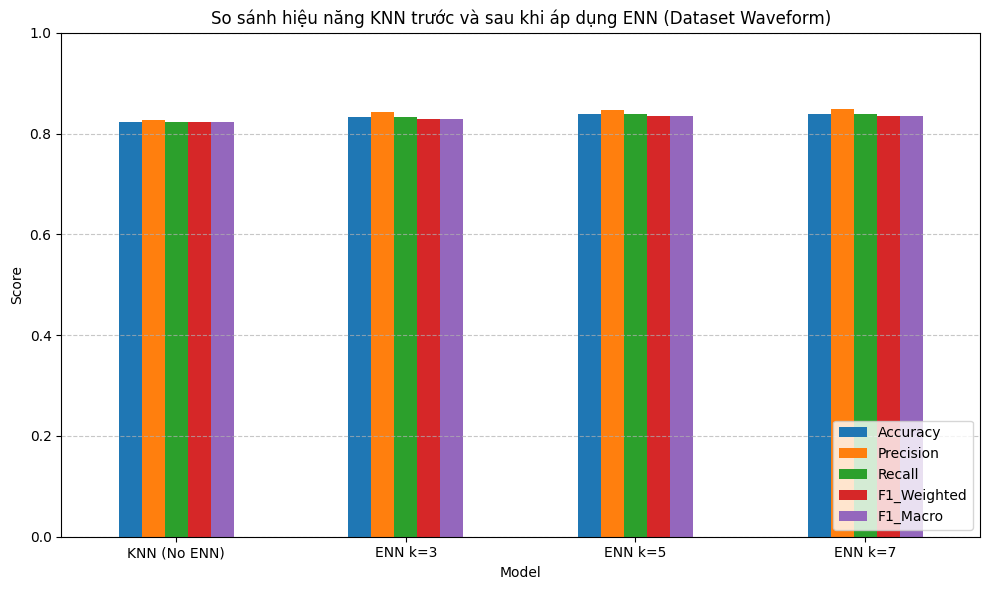

In [10]:
df_results = pd.DataFrame(results)
display(df_results)

df_results.set_index('Model').plot(kind='bar', figsize=(10, 6))
plt.title('So sánh hiệu năng KNN trước và sau khi áp dụng ENN (Dataset Waveform)')
plt.ylabel('Score')
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## Deep Dive: Strategy Comparison (all vs. mode)
In this section, we compare the two selection strategies of ENN:
- **'all'**: A sample is removed if all of its k-nearest neighbors belong to a different class.
- **'mode'**: A sample is removed if the majority of its k-nearest neighbors belong to a different class.

In [11]:
detailed_results = []
strategies = ["all", "mode"]
k_values = [3, 5, 7]

for strategy in strategies:
    for k in k_values:
        # Apply ENN
        enn = EditedNearestNeighbours(n_neighbors=k, sampling_strategy="all", kind_sel=strategy)
        X_res, y_res = enn.fit_resample(X_train_scaled, y_train)

        # Stats
        total_rem = len(y_train) - len(y_res)
        rem_rate = (total_rem / len(y_train)) * 100

        # Train & Eval
        clf = KNeighborsClassifier(n_neighbors=5)
        clf.fit(X_res, y_res)
        y_pred = clf.predict(X_test_scaled)
        metrics = evaluate_model(y_test, y_pred, f"ENN ({strategy}, k={k})")

        # Class-wise
        orig_c = pd.Series(y_train).value_counts().sort_index()
        res_c = pd.Series(y_res).value_counts().sort_index()
        class_rem = {f"Rem_Class_{c}": orig_c[c] - res_c.get(c, 0) for c in orig_c.index}

        detailed_results.append({
            "Strategy": strategy, "k": k, "Total_Removed": total_rem, "Removed_Rate_%": rem_rate,
            **metrics, **class_rem
        })

df_detailed = pd.DataFrame(detailed_results)
display(df_detailed)

ENN (all, k=3)
Accuracy  : 0.8320
Precision : 0.8434
Recall    : 0.8320
F1-score  : 0.8292
Macro F1  : 0.8290

========== CONFUSION MATRIX ==========
[[339  88  70]
 [ 14 445  35]
 [ 12  33 464]]

========== CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

           0       0.93      0.68      0.79       497
           1       0.79      0.90      0.84       494
           2       0.82      0.91      0.86       509

    accuracy                           0.83      1500
   macro avg       0.84      0.83      0.83      1500
weighted avg       0.84      0.83      0.83      1500

ENN (all, k=5)
Accuracy  : 0.8380
Precision : 0.8477
Recall    : 0.8380
F1-score  : 0.8355
Macro F1  : 0.8353

========== CONFUSION MATRIX ==========
[[346  85  66]
 [ 13 448  33]
 [ 15  31 463]]

========== CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

           0       0.93      0.70      0.79       497
           1       0.79     

,Strategy,k,Total_Removed,Removed_Rate_%,Model,Accuracy,Precision,Recall,F1_Weighted,F1_Macro,Rem_Class_0,Rem_Class_1,Rem_Class_2
0,all,3,1661,47.457143,"ENN (all, k=3)",0.832000,0.843374,0.832000,0.829240,0.829006,614,504,543
1,all,5,2035,58.142857,"ENN (all, k=5)",0.838000,0.847683,0.838000,0.835539,0.835328,722,639,674
2,all,7,2302,65.771429,"ENN (all, k=7)",0.838000,0.848495,0.838000,0.835425,0.835164,798,727,777
3,mode,3,681,19.457143,"ENN (mode, k=3)",0.829333,0.837834,0.829333,0.826834,0.826666,321,173,187
4,mode,5,647,18.485714,"ENN (mode, k=5)",0.831333,0.839193,0.831333,0.829214,0.829043,315,163,169
5,mode,7,621,17.742857,"ENN (mode, k=7)",0.827333,0.836440,0.827333,0.825035,0.824867,320,144,157


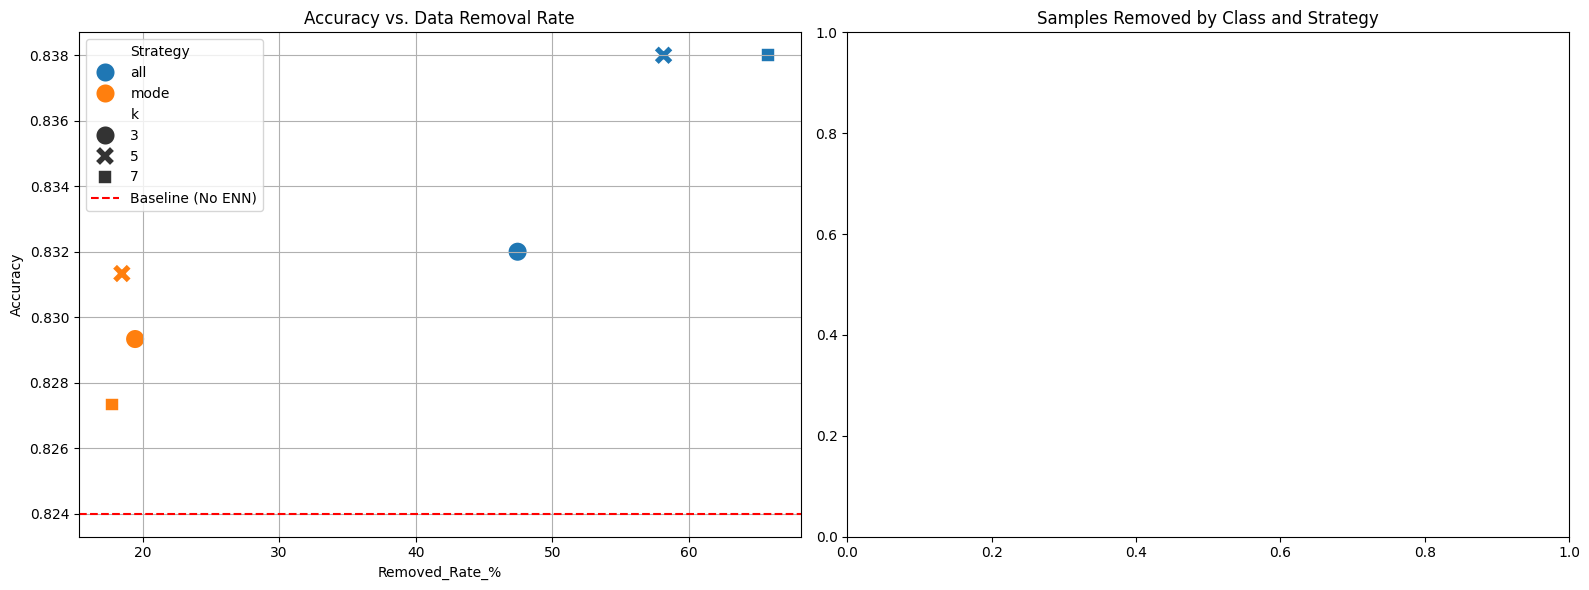

In [12]:
# Visualization of Trade-offs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy vs Removed Rate
sns.scatterplot(data=df_detailed, x='Removed_Rate_%', y='Accuracy', hue='Strategy', style='k', s=200, ax=ax1)
ax1.axhline(res_original['Accuracy'], color='red', linestyle='--', label='Baseline (No ENN)')
ax1.set_title('Accuracy vs. Data Removal Rate')
ax1.grid(True)
ax1.legend()

# Class-wise Removal Analysis
rem_cols = [c for c in df_detailed.columns if 'Removed_Class_' in c]
df_rem = df_detailed.melt(id_vars=['Strategy', 'k'], value_vars=rem_cols, var_name='Class', value_name='Count')
sns.barplot(data=df_rem, x='k', y='Count', hue='Strategy', ax=ax2)
ax2.set_title('Samples Removed by Class and Strategy')
plt.tight_layout()
plt.show()